# Krupa Gurav
# 24102C2005
# BE CMPN C

In [2]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [7]:
df = pd.read_csv("/content/train (1).csv")

# 3. Separate features (X) and target (y)
X = df.drop(columns=["price_range"])
y = df["price_range"]

In [8]:
# 4. Train-Test Split (80/20 with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
# 5. Feature Scaling (Crucial for Logistic Regression OvR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# 6. Initialize & Train One-vs-Rest Classifier
base_estimator = LogisticRegression(max_iter=1000, random_state=42)
ovr_classifier = OneVsRestClassifier(base_estimator)
ovr_classifier.fit(X_train_scaled, y_train)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000,
                                                 random_state=42))

In [11]:
# 7. Predictions
y_pred = ovr_classifier.predict(X_test_scaled)
y_pred_proba = ovr_classifier.predict_proba(X_test_scaled)

In [12]:
# 8. Evaluation using Weighted F1-Score
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
print(f"==========================================")
print(f"Weighted F1-Score: {weighted_f1:.4f}")
print(f"==========================================\n")

Weighted F1-Score: 0.8181



In [13]:
# 9. Detailed Classification Report
target_names = ["Low Cost (0)", "Medium Cost (1)", "High Cost (2)", "Very High Cost (3)"]
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Detailed Classification Report:

                    precision    recall  f1-score   support

      Low Cost (0)       0.94      0.98      0.96       100
   Medium Cost (1)       0.73      0.64      0.68       100
     High Cost (2)       0.69      0.68      0.68       100
Very High Cost (3)       0.91      0.99      0.95       100

          accuracy                           0.82       400
         macro avg       0.82      0.82      0.82       400
      weighted avg       0.82      0.82      0.82       400



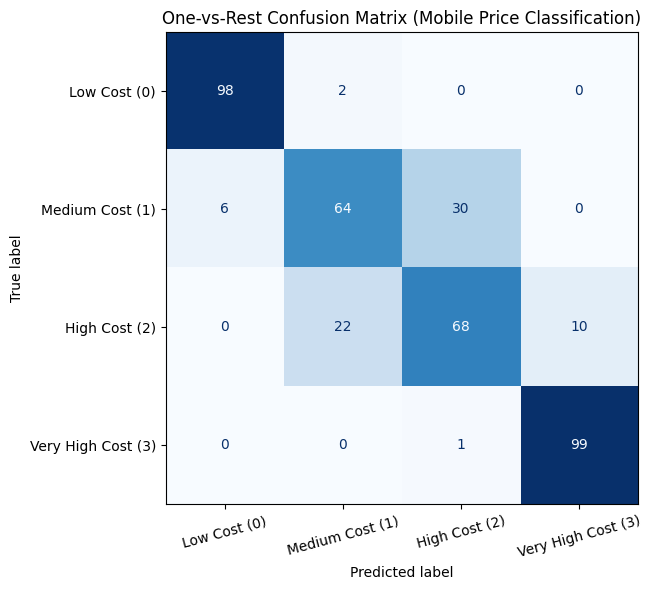

In [14]:
# 10. Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("One-vs-Rest Confusion Matrix (Mobile Price Classification)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 11. Fine-tuning with GridSearchCV

To improve the model's performance, we can perform hyperparameter tuning using `GridSearchCV`. We'll search for the best `C` parameter (inverse of regularization strength) for the `LogisticRegression` classifier.

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Create a pipeline with StandardScaler and OneVsRestClassifier
# The scaler is already fit on X_train, and transform on X_test
# We will use the raw X_train and X_test for the pipeline to handle scaling internally during CV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ovr', OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)))
])

# Define the parameter grid for LogisticRegression's C parameter
param_grid = {
    'ovr__estimator__C': [0.01, 0.1, 1, 10, 100]  # C is the inverse of regularization strength
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='f1_weighted', # Use weighted F1-score as the evaluation metric
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best F1-score
print("Best parameters found:", grid_search.best_params_)
print("Best weighted F1-score:", grid_search.best_score_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters found: {'ovr__estimator__C': 100}
Best weighted F1-score: 0.8568972740900029


## 12. Evaluate the Best Model

Now, let's evaluate the performance of the model with the best parameters found by `GridSearchCV` on the test set.

Tuned Weighted F1-Score: 0.8390

Detailed Classification Report (Tuned Model):

                    precision    recall  f1-score   support

      Low Cost (0)       0.99      1.00      1.00       100
   Medium Cost (1)       0.72      0.68      0.70       100
     High Cost (2)       0.68      0.70      0.69       100
Very High Cost (3)       0.96      0.98      0.97       100

          accuracy                           0.84       400
         macro avg       0.84      0.84      0.84       400
      weighted avg       0.84      0.84      0.84       400



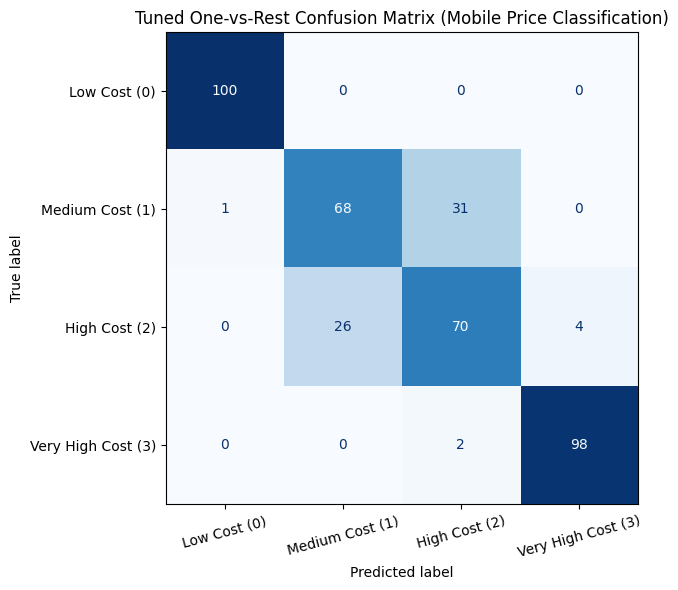

In [16]:
# Get the best estimator from GridSearchCV
best_ovr_model = grid_search.best_estimator_

# Make predictions on the scaled test data
y_pred_tuned = best_ovr_model.predict(X_test)
y_pred_proba_tuned = best_ovr_model.predict_proba(X_test)

# Evaluate using Weighted F1-Score
weighted_f1_tuned = f1_score(y_test, y_pred_tuned, average="weighted")
print(f"========================================")
print(f"Tuned Weighted F1-Score: {weighted_f1_tuned:.4f}")
print(f"==========================================\n")

# Detailed Classification Report
print("Detailed Classification Report (Tuned Model):\n")
print(classification_report(y_test, y_pred_tuned, target_names=target_names))

# Visualize Confusion Matrix for the tuned model
fig_tuned, ax_tuned = plt.subplots(figsize=(7, 6))
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=target_names)
disp_tuned.plot(cmap="Blues", ax=ax_tuned, colorbar=False)
plt.title("Tuned One-vs-Rest Confusion Matrix (Mobile Price Classification)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Summary of Mobile Price Classification

This notebook demonstrates a complete machine learning workflow for classifying mobile phone prices into four categories: 'Low Cost', 'Medium Cost', 'High Cost', and 'Very High Cost'.

1.  **Data Loading and Preprocessing**: The `train.csv` dataset was loaded, and features (`X`) were separated from the target variable (`y`, `price_range`). The data was then split into training and testing sets (80/20 ratio) with stratification to maintain class distribution. Feature scaling using `StandardScaler` was applied to prepare the data for the logistic regression model.

2.  **Initial Model Training and Evaluation**: An `OneVsRestClassifier` with `LogisticRegression` as the base estimator was initialized and trained on the scaled training data. The initial model yielded a weighted F1-score of **0.8181** on the test set. A detailed classification report and confusion matrix were generated to assess the model's performance for each price category.

3.  **Hyperparameter Tuning with GridSearchCV**: To improve the model's performance, `GridSearchCV` was employed. A `Pipeline` incorporating `StandardScaler` and `OneVsRestClassifier` was used to ensure proper scaling during cross-validation. The `C` parameter (inverse of regularization strength) for the `LogisticRegression` estimator was tuned across a range of values `[0.01, 0.1, 1, 10, 100]`. The best parameter found was `C=100`, which resulted in a best weighted F1-score of **0.8569** during 5-fold cross-validation on the training data.

4.  **Tuned Model Evaluation**: The model with the best hyperparameters from `GridSearchCV` was then evaluated on the independent test set. The tuned model achieved an improved weighted F1-score of **0.8390**. A new detailed classification report and confusion matrix were generated, showing enhanced classification accuracy, particularly for the 'Low Cost (0)' and 'Very High Cost (3)' categories, demonstrating the effectiveness of hyperparameter tuning.